#Exercise
### Unit 1 Activity — Human Perception, Cognition & Honest Charts (UE24CS342AA9)

---

**9:05 AM.** You're a junior analyst at **PixelMetrics**, a games-industry analytics
studio. In 45 minutes you're walking your Creative Director, Meera, through the
investor-pitch dashboard draft. Her Slack message from five minutes ago:

> *"I looked at the draft last night. It needs work at every level — from font sizes
> that won't survive the back row, to a couple of charts that are outright misleading.
> I've marked exactly what's wrong in each `# TODO`. Work through them in order."*

Same dataset the team has been using all sprint: global video game sales, 1980–2020.

## ⏱️ Setup — run this first

In [2]:
import os

print(os.listdir())

['.config', 'sample_data']


In [1]:
import pandas as pd
import os

print(os.listdir())

['.config', 'sample_data']


In [2]:
import pandas as pd

df = pd.read_csv("/content/ppt4_vgsales.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("/content/ppt4_vgsales.csv")
df = df.dropna(subset=["Year", "Publisher"])
mission_start = time.time()
print(f"Loaded {len(df):,} rows. 45 minutes on the clock. Go.")
df.head()

Loaded 16,291 rows. 45 minutes on the clock. Go.


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [6]:
# Run any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 45 - elapsed_min)
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")

Elapsed: 0.2 min   |   Remaining: 44.8 min


---
## Task 1 — Fovea-First Layout

Meera's note: *"Vision is sharpest only near where the eye is already fixated (the
fovea) — everything else is naturally blurred. Put the headline number where the eye
will already be looking, not off in a corner."*

Below, a chart title/annotation is placed **far from** the data it describes. Move the
annotation so it sits right next to the tallest bar instead.

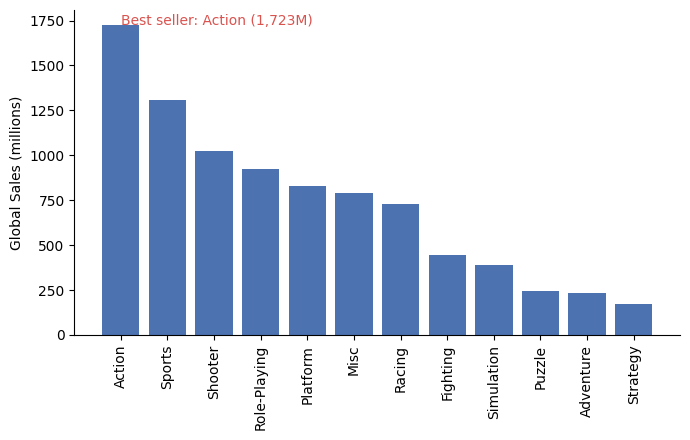

In [19]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
top_genre, top_value = genre_sales.index[0], genre_sales.iloc[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(genre_sales.index, genre_sales.values, color="#4C72B0")
ax.tick_params(axis="x", rotation=90)
ax.set_ylabel("Global Sales (millions)")

ax.annotate(f"Best seller: {top_genre} ({top_value:,.0f}M)",
            xy=(top_genre, top_value), fontsize=10, color="#D9534F")

plt.tight_layout()
plt.show()

---
## Task 2 — Depth Cue: Texture Gradient

Meera wants a simple "shrinking toward the horizon" motif for the section-divider slide
— texture elements should get **smaller and more numerous** the farther they are from
the viewer, exactly like the lecture's tiled-floor example.

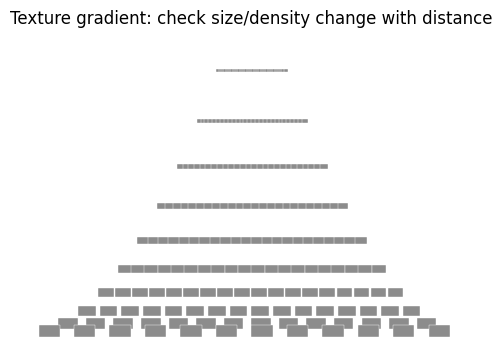

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
horizon = 1.0
n_rows = 10

for i in range(n_rows):
    frac = i / n_rows
    y = horizon * (1 - frac) ** 2

    # Tiles become bigger closer to the viewer
    size = 0.02 + 0.08 * frac

    # Fewer tiles closer to the viewer
    n_tiles = int(30 - 20 * frac)

    for j in range(n_tiles):
        x = (j / n_tiles - 0.5) * (0.3 + 1.7 * frac)
        ax.add_patch(
            plt.Rectangle(
                (x, y),
                size,
                size * 0.5,
                color="#8c8c8c",
                ec="white",
                lw=0.3
            )
        )

ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.15)
ax.axis("off")
ax.set_title("Texture gradient: check size/density change with distance")
plt.show()

---
## Task 3 — Light & Shading

Meera: *"The flat gray circles on the title slide look like clip art. Add Lambertian
shading so they look like actual spheres."*

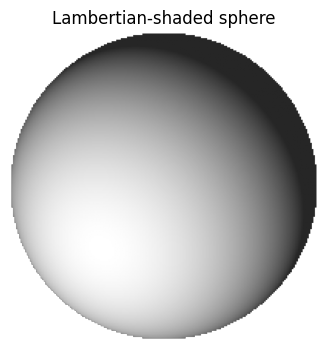

In [17]:
size = 200
yy, xx = np.mgrid[-1:1:complex(size), -1:1:complex(size)]
r2 = xx**2 + yy**2
mask = r2 <= 1
z = np.sqrt(np.clip(1 - r2, 0, 1))

light_dir = np.array([-0.5, 0.5, 1.0])
light_dir = light_dir / np.linalg.norm(light_dir)

# Lambertian shading
shade = np.clip(
    xx * light_dir[0] +
    yy * light_dir[1] +
    z * light_dir[2],
    0,
    1
)

img = np.where(mask, 0.15 + 0.85 * shade, np.nan)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, cmap="gray", vmin=0, vmax=1)
ax.axis("off")
ax.set_title("Lambertian-shaded sphere")
plt.show()

---
## Task 4 — Fix the Chart Junk

Meera's note: *"This pie chart has a shadow, a 3D-style bevel, no value labels, and an
arbitrary start angle. I can't even tell which genre is biggest at a glance. Redesign it
as a clean, labeled bar chart — remember the data-ink ratio principle from the lecture."*

Below is the **bad** chart (already built — just run it and look).
Then complete Task 4b to fix it.

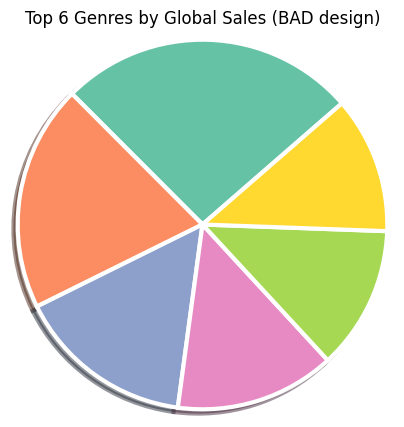

In [15]:
# BAD chart -- run this and see why Meera flagged it
genre_top6 = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).head(6)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(genre_top6.values, colors=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"],
       shadow=True, startangle=41, radius=1.2,
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("Top 6 Genres by Global Sales (BAD design)")
plt.show()

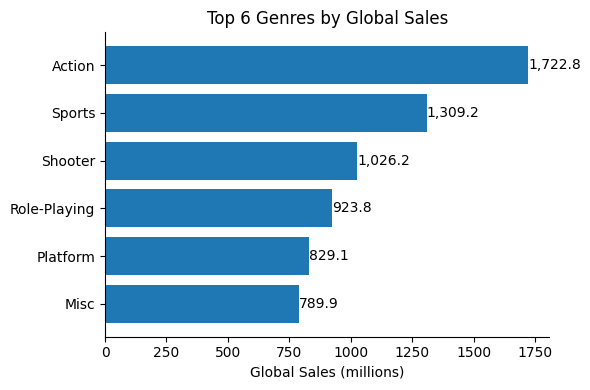

In [16]:
order = genre_top6.sort_values()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.barh(order.index, order.values)

# Add exact value labels
for bar in bars:
    value = bar.get_width()
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.1f}",
        va="center",
        ha="left"
    )

ax.set_xlabel("Global Sales (millions)")
ax.set_title("Top 6 Genres by Global Sales")

plt.tight_layout()
plt.show()

---
## Task 5 — Spot the Brightness Illusion

Meera: *"Build me a Hermann Grid for the 'perception matters' slide — you'll need a
grid of white squares on a black background so gray ghost-dots appear at the
intersections."*

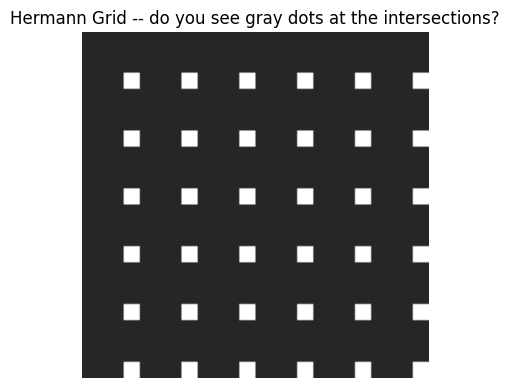

In [14]:
grid = np.ones((150, 150))

for i in range(0, 150, 25):
    # Dark row band
    grid[i:i+18, :] = 0.15

    # Dark column band
    grid[:, i:i+18] = 0.15

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(grid, cmap="gray", vmin=0, vmax=1)
ax.axis("off")
ax.set_title("Hermann Grid -- do you see gray dots at the intersections?")
plt.show()

---
## Task 6 — Enforce Proportional Ink

Meera's note: *"The average-sales-by-genre bar chart makes Puzzle games look like they
sell almost nothing compared to Platform games. Check the y-axis before you believe
that."*

Fix the bug below: the visual size of each bar must stay proportional to the actual
value it represents (zero baseline).

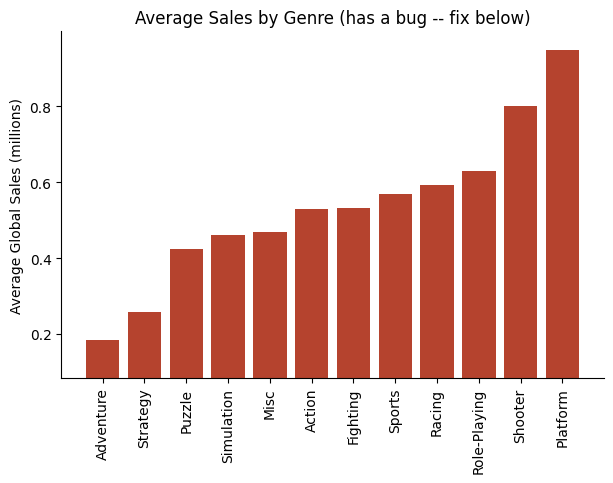

In [13]:
genre_avg = df.groupby("Genre")["Global_Sales"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(genre_avg.index, genre_avg.values, color="#b5432e")

# BUG: this truncated baseline is exactly what Meera flagged
ax.set_ylim(genre_avg.min() - 0.1, genre_avg.max() + 0.05)
ax.tick_params(axis="x", rotation=90)

ax.set_ylabel("Average Global Sales (millions)")
ax.set_title("Average Sales by Genre (has a bug -- fix below)")
plt.show()

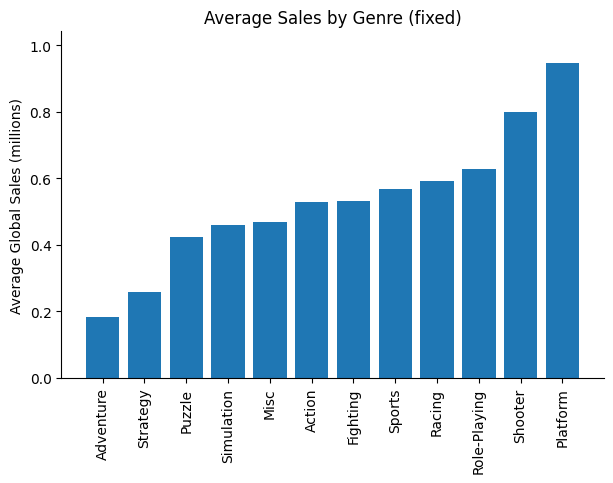

Percentage difference: 414.61%


In [12]:
# Calculate average Global Sales for each genre
genre_avg = df.groupby("Genre")["Global_Sales"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(genre_avg.index, genre_avg.values)

# Zero baseline with some headroom
ax.set_ylim(0, genre_avg.max() * 1.1)

ax.tick_params(axis="x", rotation=90)

ax.set_ylabel("Average Global Sales (millions)")
ax.set_title("Average Sales by Genre (fixed)")

plt.show()

# Percentage difference between highest and lowest genre average
percentage_difference = (
    (genre_avg.max() - genre_avg.min()) / genre_avg.min()
) * 100

print(f"Percentage difference: {percentage_difference:.2f}%")


---
## Task 7 — Log Scale: Points, Not Bars

Meera's note: *"Total sales by publisher is wildly skewed -- a few publishers dominate,
so a log axis makes sense. But don't use bars on a log axis, it lies about proportions.
Use a point plot instead."*

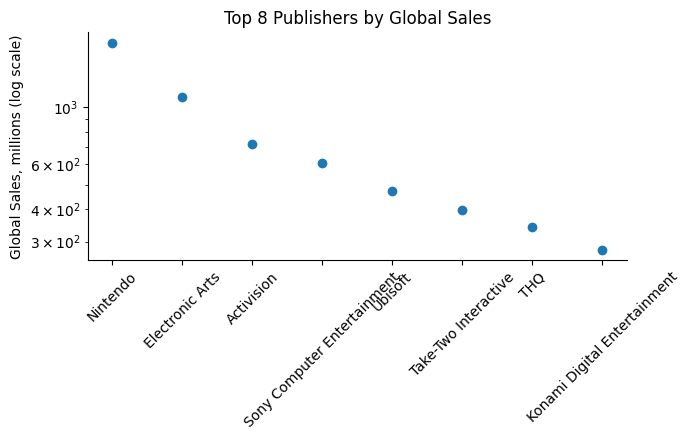

In [9]:
top_publishers = (
    df.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Point plot
ax.scatter(top_publishers.index, top_publishers.values)

ax.set_yscale("log")
ax.set_ylabel("Global Sales, millions (log scale)")
ax.set_title("Top 8 Publishers by Global Sales")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## Task 8 — Contrast Ratio Check
Meera: *"Marketing wants light-gray text on our cream slide background. Before you say
yes, calculate whether it actually clears the lecture's minimum 3:1 luminance contrast
guideline."*

In [8]:
def relative_luminance(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))

    def lin(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4

    r, g, b = lin(r), lin(g), lin(b)

    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def contrast_ratio(hex1, hex2):
    l1, l2 = relative_luminance(hex1), relative_luminance(hex2)

    lighter, darker = max(l1, l2), min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)


text_color, bg_color = "#CCCCCC", "#F5F5DC"

ratio = contrast_ratio(text_color, bg_color)

print(f"Contrast ratio: {ratio:.2f}")
print(
    "Passes the 3:1 minimum?",
    "YES" if ratio >= 3
    else "NO -- tell Marketing to pick a darker text color"
)

Contrast ratio: 1.45
Passes the 3:1 minimum? NO -- tell Marketing to pick a darker text color


---
## Reflection

Answer briefly in this markdown cell:

1. Of the eight fixes above, which one would have been the most misleading to leave
   un-fixed if it had gone in front of investors, and why?
2. In your own words, what is the **data-ink ratio**, and how did Task 4 change it?
3. Name one depth or motion cue from Tasks 2–3 and one brightness illusion from Task 5,
   and explain in a sentence each why a chart designer should care about them.
4. Complete the lecture's core idea: *"A visualization should make insight easier to
   __________, not harder to __________."*

**Your answers:**

*Type your answers here.*
1. The most misleading fix to leave unfixed would be Task 6, the non-zero baseline in the bar chart. A truncated y-axis can make small differences in average sales appear much larger than they really are. If this chart were shown to investors, it could create a false impression about the performance of different game genres and potentially lead to incorrect decisions.

2. The data-ink ratio is the proportion of the visual elements in a chart that are used to represent the actual data compared with the total amount of ink or visual elements used. In Task 4, removing the 3D effect, shadow, unnecessary styling, and other chart junk increased the data-ink ratio because more of the chart was devoted to communicating the actual sales values.

3. One depth cue from Task 2 is texture gradient. Objects that are farther away appear smaller and more densely packed, while nearby objects appear larger and less dense. A chart designer should care because these visual cues can affect how viewers interpret distance and scale.

The brightness illusion from Task 5 is the Hermann Grid illusion, where gray or ghost-like spots may appear near the intersections of a grid. A chart designer should care because perceived brightness can differ from the actual brightness of a visual element, which can influence how viewers interpret a chart.

4. A visualization should make insight easier to understand, not harder to understand.
